In lecture 22 of mcs 320, we consider symbolic, numeric, and implicit differentiation.

# 1. Symbolic Differentiation

Consider an expression ``f`` which depends on ``x``.

In [1]:
f = sin(2*pi*x)
f

sin(2*pi*x)

Let us compute the value of the derivative of ``f`` at ``x = 1``.

In [2]:
f1 = diff(f, x)
f1

2*pi*cos(2*pi*x)

In [3]:
f1(x = 1)

2*pi

We can compute the 5-th derivative as follows:

In [4]:
diff(f, x, 5)

32*pi^5*cos(2*pi*x)

or via the method ``diff`` applied to the expression ``f``.

In [5]:
f.diff(x, 5)

32*pi^5*cos(2*pi*x)

With functions in several variables, we can compute the derivatives all at once.  Consider a random polynomial with rational coefficients in the variables ``x`` and ``y``.

In [6]:
P.<x,y> = QQ[]
q = P.random_element(degree=5, terms=8)
q

x^4*y + 2/5*x*y^4 - 7*y^5 + x^3*y - 1/2*x^2*y^2

In [7]:
f(x,y) = SR(q).subs({x: x, y: y})
f

(x, y) |--> x^4*y + 2/5*x*y^4 - 7*y^5 + x^3*y - 1/2*x^2*y^2

In [8]:
g = f.diff()
g

(x, y) |--> (4*x^3*y + 2/5*y^4 + 3*x^2*y - x*y^2, x^4 + 8/5*x*y^3 - 35*y^4 + x^3 - x^2*y)

Observe that ``g`` is a function which returns a tuple.  The ``g`` is the *gradient* of ``f``.

In [9]:
h = g.diff()
h

[         (x, y) |--> 12*x^2*y + 6*x*y - y^2 (x, y) |--> 4*x^3 + 8/5*y^3 + 3*x^2 - 2*x*y]
[(x, y) |--> 4*x^3 + 8/5*y^3 + 3*x^2 - 2*x*y      (x, y) |--> 24/5*x*y^2 - 140*y^3 - x^2]

In [10]:
type(h)

<class 'sage.matrix.matrix_generic_dense.Matrix_generic_dense'>

Observe that ``h`` is a matrix.  The matrix of all partial derivatives of a function in several variables is called the *Hessian* of the function.

# 2. Numeric Differentiation

Numeric differentiation is available as ``derivative`` of ``scipy.misc``.

Because ``numdiff`` will be deprecated, try ``derivative`` of ``scipy.differentiate``.

In [11]:
from scipy.misc import derivative as numdiff
# from scipy.differentiate import derivative

Let us apply this to the problem of computing the derivative of ``sin(2*pi*x)`` at ``x = 1``.

For this to work properly, we have to use the ``sin`` and ``pi`` of ``numpy``.

In [12]:
import numpy

In [13]:
nf = lambda x: numpy.sin(2*numpy.pi*x)

Because ``numdiff`` will be deprecated, try ``derivative`` of ``scipy.differentiate``.

In [14]:
# from scipy.differentiate import derivative

In [15]:
numdiff(nf, 1.0, dx=1.0e-2)
# derivative(nf, 1.0)

/tmp/ipykernel_10083/2127807179.py:1: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  numdiff(nf, RealNumber('1.0'), dx=RealNumber('1.0e-2'))


6.279051952931303

The value for ``dx`` defines the step size $h$.

We can improve on the numerical value by decreasing the step size and taking more points, specifying the value for ``order``.

In [16]:
numdiff(nf, 1.0, dx=1.0e-4, order=5)

/tmp/ipykernel_10083/2780584361.py:1: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  numdiff(nf, RealNumber('1.0'), dx=RealNumber('1.0e-4'), order=Integer(5))


6.283185307180939

In [17]:
2*numpy.pi

6.283185307179586

# 3. Implicit Differentiation

Take a random point on the unit circle and compute the slope of the tangent line.

In [18]:
x, y = var('x, y')
circle = x^2 + y^2 - 1
circle

x^2 + y^2 - 1

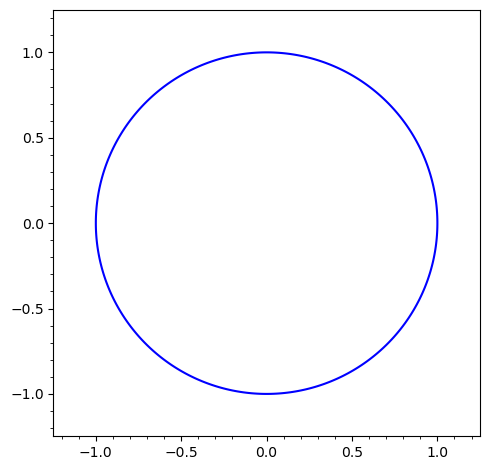

In [19]:
plotcircle = implicit_plot(circle, (x, -1.2, 1.2), (y, -1.2, 1.2), aspect_ratio=1)
show(plotcircle)

A random point on the unit circle is defined by $(\cos(t), \sin(t))$ for $t$ a random angle in $[-\pi, \pi[$.

In [20]:
angle = RR(pi)*RR.random_element()
angle

2.97687902080677

In [21]:
(a, b) = (cos(angle), sin(angle))
(a, b)

(-0.986465351382411, 0.163969846380292)

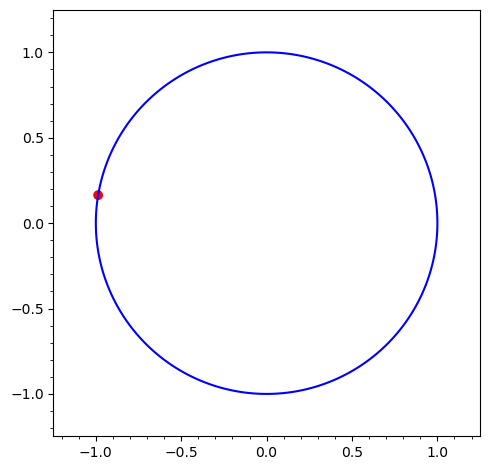

In [22]:
plotpoint = point((a, b), size='50', color='red')
show(plotcircle + plotpoint)

Now we want to compute the tangent line through the point on the circle. 

To apply implicit differentiation, we must declare ``y(x)``, that is ``y`` as a function of ``x``.  For this function, we introduce a new variable ``Y``.

In [23]:
Y = function('Y')(x)
print(Y, 'has type', type(Y))

Y(x) has type <class 'sage.symbolic.expression.Expression'>


In [24]:
dy = diff(Y, x)
dy

diff(Y(x), x)

In [25]:
Ycircle = circle(y=Y)
Ycircle

x^2 + Y(x)^2 - 1

In [26]:
dc = diff(Ycircle, x)
dc

2*Y(x)*diff(Y(x), x) + 2*x

In [27]:
sol = solve(dc, dy)
sol

[diff(Y(x), x) == -x/Y(x)]

In [28]:
solrhs = sol[0].rhs()
solrhs

-x/Y(x)

In [29]:
slope = solrhs.subs({x: a}).subs({Y(x=a): b})
slope

6.01613877892233

In [30]:
tangent = y - b - slope*(x - a)
tangent

-6.01613877892233*x + y - 6.09868230089525

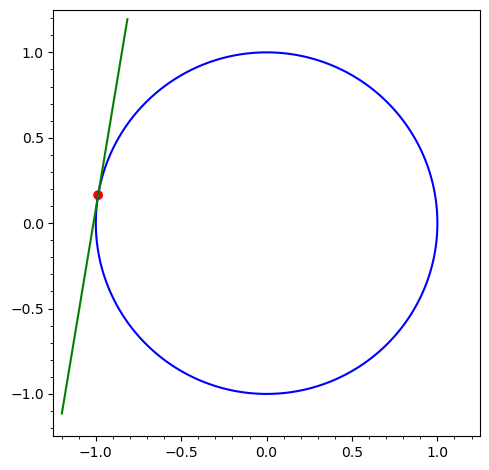

In [31]:
plotline = implicit_plot(tangent, (x, -1.2, 1.2), (y, -1.2, 1.2), color='green')
show(plotcircle+plotpoint+plotline)